In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import os
import h5py
from anndata import AnnData

import scanpy as sc
import squidpy as sq
import bin2cell as b2c

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GAE, GCNConv

import networkx as nx
from scipy.spatial import Delaunay
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import sklearn
import sklearn.neighbors
import scipy.sparse as sp

/opt/anaconda3/envs/spatial_env/lib/python3.9/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 12.0.1. Please consider upgrading.
  warnings.warn(
/opt/anaconda3/envs/spatial_env/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Helper functions

In [3]:
# From SpaGRA paper
def prefilter_genes(adata, min_cells=3):
    """
    Filters genes to retain only those expressed in at least `min_cells` cells.
    """
    sc.pp.filter_genes(adata, min_cells=min_cells)
    return adata

def Cal_Spatial_Net(adata, rad_cutoff=None, k_cutoff=None, model='Radius', Spatial_uns="Spatial_Net"):
    """
    Construct the spatial neighbor network for an AnnData object.
    
    Parameters:
        adata       : AnnData object with spatial coordinates stored in adata.obsm['spatial']
        rad_cutoff  : If using 'Radius' model, spots within this Euclidean distance will be connected
        k_cutoff    : If using 'KNN' model, the number of nearest neighbors for each spot (not used here)
        model       : Either 'Radius' or 'KNN'. Default is 'Radius'.
        Spatial_uns : The key under which the resulting spatial network (DataFrame) is stored in adata.uns.
    
    The function calculates pairwise distances based on the spatial coordinates and then builds a DataFrame 
    of neighbor connections (edges) with columns 'Cell1', 'Cell2', and 'Distance'.
    """
    print('------Calculating spatial graph...')
    assert (model in ['Radius', 'KNN']), "Model must be 'Radius' or 'KNN'"

    # Create a DataFrame from the spatial coordinates.
    coor = pd.DataFrame(adata.obsm['spatial'])
    coor.index = adata.obs.index
    coor.columns = ['imagerow', 'imagecol']

    if model == 'Radius':
        nbrs = sklearn.neighbors.NearestNeighbors(radius=rad_cutoff).fit(coor)
        distances, indices = nbrs.radius_neighbors(coor, return_distance=True)
        KNN_list = []
        for it in range(indices.shape[0]):
            # Each row gives a set of neighbors (including self)
            # The zip below creates tuples (current_index, neighbor_index, distance)
            KNN_list.append(pd.DataFrame(zip([it] * indices[it].shape[0], indices[it], distances[it])))
    elif model == 'KNN':
        nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k_cutoff + 1).fit(coor)
        distances, indices = nbrs.kneighbors(coor)
        KNN_list = []
        for it in range(indices.shape[0]):
            KNN_list.append(pd.DataFrame(zip([it] * indices[it].shape[0], indices[it, :], distances[it, :])))
    
    # Combine all neighbor data into one DataFrame.
    KNN_df = pd.concat(KNN_list)
    KNN_df.columns = ['Cell1', 'Cell2', 'Distance']
    
    # Remove self-loops (distance == 0).
    Spatial_Net = KNN_df.loc[KNN_df['Distance'] > 0,].copy()
    
    # Map numerical indices back to cell (spot) names.
    id_cell_trans = dict(zip(range(coor.shape[0]), coor.index))
    Spatial_Net['Cell1'] = Spatial_Net['Cell1'].map(id_cell_trans)
    Spatial_Net['Cell2'] = Spatial_Net['Cell2'].map(id_cell_trans)
    
    adata.uns[Spatial_uns] = Spatial_Net
    print(f"Spatial network with {len(Spatial_Net)} edges stored in adata.uns['{Spatial_uns}']")
    return adata

def Transfer_Data(adata):
    """
    Convert an AnnData object with a spatial network in adata.uns['Spatial_Net'] into a graph representation.
    
    Returns
    -------
    G    : a sparse COO-format adjacency matrix (with self-loops added)
    X    : the gene expression feature matrix (as a dense NumPy array)
    """
    # Copy the spatial network DataFrame
    G_df = adata.uns['Spatial_Net'].copy()
    
    # Map the cell (spot) names to integer indices
    cells = np.array(adata.obs_names)
    cells_id_tran = dict(zip(cells, range(len(cells))))
    G_df['Cell1'] = G_df['Cell1'].map(cells_id_tran)
    G_df['Cell2'] = G_df['Cell2'].map(cells_id_tran)
    
    # Create a sparse adjacency matrix from the edge list; note that we are using unit weights.
    n = adata.n_obs
    G = sp.coo_matrix((np.ones(G_df.shape[0]), (G_df['Cell1'], G_df['Cell2'])), shape=(n, n))
    # Add self-loops so that every node is connected to itself
    G = G + sp.eye(n)
    
    # Get the feature matrix from adata.X.
    # If adata.X is sparse, convert it to dense.
    if hasattr(adata.X, "todense"):
        X = np.array(adata.X.todense())
    else:
        X = np.array(adata.X)
    
    return G, X

# Visium data

In [4]:
# # Path v2 data
# spatial_dir = "../data/v2_data"

# # Read Visium dataset
# adata_v2 = sc.read_visium(path=spatial_dir)

# load the pre-processed dataset from Squidpy
img_v2 = sq.datasets.visium_hne_image()
adata_v2 = sq.datasets.visium_hne_adata()

In [5]:
# Print the summary of the AnnData object
print(adata_v2)

# Check the first few rows of metadata
print(adata_v2.obs.head())

# Check the first few rows of gene information
print(adata_v2.var.head())

# Check unique gene counts and feature types
print(adata_v2.var['feature_types'].value_counts())

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
                    in_tissue  array_row  array_col  n_genes_by_counts  \
AAACAAGTATCTCCCA-1          1         50    

# Visium HD data

In [6]:
# Load Visium HD dataset using bin2cell
### Load Data

# Define paths to required files
path = "../data/mouse_hd_data/binned_outputs_mousebrain_hd/square_016um/"
source_image_path = "../data/mouse_hd_data/Visium_HD_Mouse_Brain_tissue_image.tif"
spaceranger_image_path = "../data/mouse_hd_data/spatial_mousebrain_hd"

# Load data
adata_hd = b2c.read_visium(path, 
                        source_image_path = source_image_path, 
                        spaceranger_image_path = spaceranger_image_path
                       )
adata_hd.var_names_make_unique()

anndata.py (1756): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1756): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [7]:
# Summary of observations (cells) and variables (genes)
print(adata_hd)

# Check the first few rows of metadata
print(adata_hd.obs.head())

# Check the first few rows of gene information
print(adata_hd.var.head())

# Check unique gene counts and feature types
print(adata_hd.var['feature_types'].value_counts())

AnnData object with n_obs × n_vars = 98917 × 19059
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
                       in_tissue  array_row  array_col
s_016um_00052_00082-1          1         52         82
s_016um_00150_00268-1          1        150        268
s_016um_00144_00175-1          1        144        175
s_016um_00165_00109-1          1        165        109
s_016um_00297_00147-1          1        297        147
                  gene_ids    feature_types genome
Xkr4    ENSMUSG00000051951  Gene Expression   mm10
Rp1     ENSMUSG00000025900  Gene Expression   mm10
Sox17   ENSMUSG00000025902  Gene Expression   mm10
Lypla1  ENSMUSG00000025903  Gene Expression   mm10
Tcea1   ENSMUSG00000033813  Gene Expression   mm10
feature_types
Gene Expression    19059
Name: count, dtype: int64


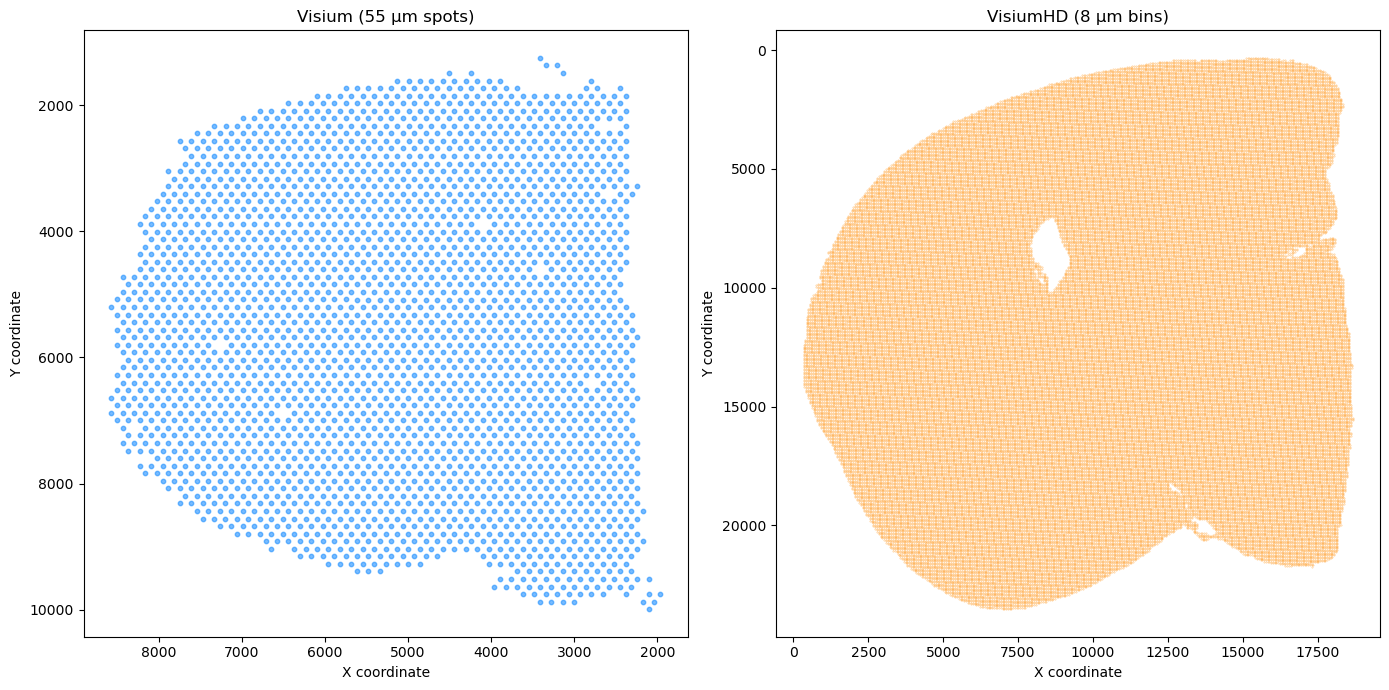

In [8]:
# Get Visium spatial coordinates
coords_v2 = adata_v2.obsm["spatial"]
coords_hd = adata_hd.obsm["spatial"]

# Plot both spatial layouts side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

# Visium (55 µm spots)
axs[0].scatter(coords_v2[:, 0], coords_v2[:, 1], c='dodgerblue', s=10, alpha=0.6)
axs[0].invert_yaxis()
axs[0].invert_xaxis() 
axs[0].set_title("Visium (55 µm spots)")
axs[0].set_xlabel("X coordinate")
axs[0].set_ylabel("Y coordinate")

# VisiumHD (8 µm bins)
axs[1].scatter(coords_hd[:, 0], coords_hd[:, 1], c='darkorange', s=0.1, alpha=0.5)
axs[1].invert_yaxis()
axs[1].set_title("VisiumHD (8 µm bins)")
axs[1].set_xlabel("X coordinate")
axs[1].set_ylabel("Y coordinate")

plt.tight_layout()
plt.show()

## Identify the Common Gene  & Subset Each AnnData Object to the Common Gene Set

In [9]:
adata_v2.var_names_make_unique()
prefilter_genes(adata_v2, min_cells=3)
sc.pp.highly_variable_genes(adata_v2, flavor="seurat_v3", n_top_genes=1000)
sc.pp.normalize_per_cell(adata_v2)
sc.pp.log1p(adata_v2)

adata_hd.var_names_make_unique()
prefilter_genes(adata_hd, min_cells=3)
sc.pp.highly_variable_genes(adata_hd, flavor="seurat_v3", n_top_genes=1000)
sc.pp.normalize_per_cell(adata_hd)
sc.pp.log1p(adata_hd)

genes_v2 = adata_v2.var_names
genes_hd = adata_hd.var_names

# Compute the intersection (common genes between both datasets)
common_genes = np.intersect1d(genes_v2, genes_hd)
print("Number of common genes:", len(common_genes))

# Subset and copy the datasets for safety
adata_v2_subset = adata_v2[:, common_genes].copy()
adata_hd_subset = adata_hd[:, common_genes].copy()

print("Visium v2 subset:", adata_v2_subset)
print("Visium HD subset:", adata_hd_subset)

_highly_variable_genes.py (75): `flavor='seurat_v3'` expects raw count data, but non-integers were found.


Number of common genes: 14842
Visium v2 subset: AnnData object with n_obs × n_vars = 2688 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'log1p'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Visium HD subset: AnnData object with n_obs × n_vars = 98917 

## Produce spatial networks for Visium v2 & Visium HD

In [10]:
# Use a radius cutoff of 400 pixels (or units) for the Visium v2 data
Cal_Spatial_Net(adata_v2_subset, rad_cutoff=400)

------Calculating spatial graph...
Spatial network with 75928 edges stored in adata.uns['Spatial_Net']


AnnData object with n_obs × n_vars = 2688 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'log1p', 'Spatial_Net'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [11]:
adata_hd_subset

AnnData object with n_obs × n_vars = 98917 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p'
    obsm: 'spatial'

In [12]:
# Subsampling the data
sample_idx = np.random.choice(adata_hd_subset.obs_names, size=10000, replace=False)
adata_hd_subset = adata_hd_subset[sample_idx].copy()
Cal_Spatial_Net(adata_hd_subset, rad_cutoff=150)

------Calculating spatial graph...
Spatial network with 19948 edges stored in adata.uns['Spatial_Net']


AnnData object with n_obs × n_vars = 10000 × 14842
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'spatial', 'hvg', 'log1p', 'Spatial_Net'
    obsm: 'spatial'

## Converting the Spatial Networks to Graphs and Features

In [13]:
# For Visium v2 data
G_v2, X_v2 = Transfer_Data(adata_v2_subset)
print("Visium v2: Adjacency shape:", G_v2.shape, "Feature matrix shape:", X_v2.shape)

# For Visium HD subset 
G_hd, X_hd = Transfer_Data(adata_hd_subset)
print("Visium HD: Adjacency shape:", G_hd.shape, "Feature matrix shape:", X_hd.shape)

Visium v2: Adjacency shape: (2688, 2688) Feature matrix shape: (2688, 14842)
Visium HD: Adjacency shape: (10000, 10000) Feature matrix shape: (10000, 14842)


In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

# ---------- Dataset Wrapper ----------
class GraphDataset(Dataset):
    def __init__(self, adj: np.ndarray, feats: np.ndarray):
        edge_index = self.adj_to_edge_index(adj)
        x = torch.from_numpy(feats).float()
        self.data = Data(x=x, edge_index=edge_index)

    @staticmethod
    def adj_to_edge_index(adj: np.ndarray):
        rows, cols = np.nonzero(adj)
        return torch.tensor([rows, cols], dtype=torch.long)

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        return self.data

# ---------- Graph VAE ----------
class GraphVAE(nn.Module):
    def __init__(self, in_feats, hidden_dim, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(in_feats, hidden_dim)
        self.conv_mu = GCNConv(hidden_dim, latent_dim)
        self.conv_logvar = GCNConv(hidden_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, hidden_dim)
        self.conv_dec1 = GCNConv(hidden_dim, hidden_dim)
        self.conv_dec2 = GCNConv(hidden_dim, in_feats)

    def encode(self, x, edge_index):
        h = torch.relu(self.conv1(x, edge_index))
        return self.conv_mu(h, edge_index), self.conv_logvar(h, edge_index)

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z, edge_index):
        h = torch.relu(self.fc_decode(z))
        h = torch.relu(self.conv_dec1(h, edge_index))
        return self.conv_dec2(h, edge_index)

    def forward(self, x, edge_index):
        mu, logvar = self.encode(x, edge_index)
        z = self.reparametrize(mu, logvar)
        recon_x = self.decode(z, edge_index)
        return recon_x, z, mu, logvar

# ---------- Discriminator ----------
class FC_Classifier(nn.Module):
    def __init__(self, nz, n_hidden=512, n_out=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nz, n_hidden), nn.ReLU(inplace=True),
            nn.Linear(n_hidden, n_hidden), nn.ReLU(inplace=True),
            nn.Linear(n_hidden, n_out)
        )

    def forward(self, x):
        return self.net(x)

# ---------- Loss & DEC utilities ----------
MSE = nn.MSELoss()
BCE = nn.BCEWithLogitsLoss()

def compute_KL(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

def compute_q(z, mu, alpha=1.0):
    diff = z.unsqueeze(1) - mu.unsqueeze(0)
    dist2 = torch.sum(diff**2, dim=2)
    q = (1 + dist2/alpha)**(-(alpha+1)/2)
    return q / torch.sum(q, dim=1, keepdim=True)

def compute_p(q):
    weight = q**2 / torch.sum(q, dim=0, keepdim=True)
    return weight / torch.sum(weight, dim=1, keepdim=True)

# ---------- Training step with DEC & SE ----------
def train_autoencoders(netA, netB, disc, C_A, C_B, mu_A, mu_B,
                       optA, optB, dataA, dataB,
                       alpha=1.0, beta=0.1, gamma_se=0.1, gamma_dec=0.1, lambda_reg=1e-3):
    netA.train(); netB.train(); disc.eval()
    optA.zero_grad(); optB.zero_grad()
    xA, eA = dataA.x, dataA.edge_index
    xB, eB = dataB.x, dataB.edge_index
    recA, zA, muA, logvarA = netA(xA, eA)
    recB, zB, muB, logvarB = netB(xB, eB)
    # Reconstruction + KL
    loss_rec = MSE(recA, xA) + MSE(recB, xB)
    loss_kl  = compute_KL(muA, logvarA) + compute_KL(muB, logvarB)
    # Adversarial loss
    logitsB = disc(zB)
    labels_gen = torch.zeros(zB.size(0), device=zB.device)
    loss_adv = BCE(logitsB[:,0] - logitsB[:,1], labels_gen)
    # Self-expression (SE) loss
    I_A = torch.eye(C_A.size(0), device=C_A.device)
    maskA = C_A * (1 - I_A)
    I_B = torch.eye(C_B.size(0), device=C_B.device)
    maskB = C_B * (1 - I_B)
    recon_zA = maskA @ zA
    recon_zB = maskB @ zB
    loss_se  = MSE(recon_zA, zA) + MSE(recon_zB, zB)
    loss_reg = lambda_reg * (torch.norm(maskA, p=1) + torch.norm(maskB, p=1))
    # DEC loss
    qA = compute_q(zA, mu_A)
    pA = compute_p(qA)
    qB = compute_q(zB, mu_B)
    pB = compute_p(qB)
    loss_dec = torch.sum(pA * torch.log(pA/(qA+1e-10))) + torch.sum(pB * torch.log(pB/(qB+1e-10)))
    # Total
    loss = (alpha*(loss_rec + loss_kl)
            + beta*loss_adv
            + gamma_se*loss_se
            + gamma_dec*loss_dec
            + loss_reg)
    loss.backward()
    optA.step(); optB.step()
    return loss.item(), loss_se.item(), loss_dec.item()

# ---------- Discriminator step ----------
def train_discriminator(netA, netB, disc, optD, dataA, dataB):
    netA.eval(); netB.eval(); disc.train()
    optD.zero_grad()
    with torch.no_grad():
        _, zA, _, _ = netA(dataA.x, dataA.edge_index)
        _, zB, _, _ = netB(dataB.x, dataB.edge_index)
    logitsA = disc(zA)
    logitsB = disc(zB)
    labelsA = torch.ones(zA.size(0), device=zA.device)
    labelsB = torch.zeros(zB.size(0), device=zB.device)
    loss = 0.5 * (
        BCE(logitsA[:,0] - logitsA[:,1], labelsA)
        + BCE(logitsB[:,0] - logitsB[:,1], labelsB)
    )
    loss.backward()
    optD.step()
    return loss.item()

# ---------- Main ----------
if __name__ == "__main__":
    # Load and wrap graphs
    G_v2, X_v2 = Transfer_Data(adata_v2_subset)
    G_hd, X_hd = Transfer_Data(adata_hd_subset)
    data_v2 = GraphDataset(G_v2, X_v2)[0]
    data_hd = GraphDataset(G_hd, X_hd)[0]
    # Models & params
    in_dim, hidden_dim, latent_dim = X_v2.shape[1], 256, 128
    nA, nB, n_clusters = X_v2.shape[0], X_hd.shape[0], 10
    netV2 = GraphVAE(in_dim, hidden_dim, latent_dim)
    netHD = GraphVAE(in_dim, hidden_dim, latent_dim)
    disc  = FC_Classifier(latent_dim)
    # Initialize DEC cluster centers in latent space (n_clusters, latent_dim)
    mu_A = nn.Parameter(torch.randn(n_clusters, latent_dim))
    mu_B = nn.Parameter(torch.randn(n_clusters, latent_dim))
    # Initialize SE coefficient matrices (nA, nA), (nB, nB)
    C_A = nn.Parameter(torch.zeros(nA, nA))
    C_B = nn.Parameter(torch.zeros(nB, nB))
    # Optimizers
    optV2 = optim.Adam(list(netV2.parameters()) + [C_A, mu_A], lr=1e-3)
    optHD = optim.Adam(list(netHD.parameters()) + [C_B, mu_B], lr=1e-3)
    optD  = optim.Adam(disc.parameters(), lr=1e-3)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    netV2.to(device); netHD.to(device); disc.to(device)
    C_A.data.fill_(0); C_B.data.fill_(0)
    mu_A.data = mu_A.data.to(device)
    mu_B.data = mu_B.data.to(device)
    data_v2 = data_v2.to(device)
    data_hd = data_hd.to(device)

    # Training loop
    for epoch in range(1, 201):
        loss_ae, loss_se, loss_dec = train_autoencoders(
            netV2, netHD, disc, C_A, C_B, mu_A, mu_B,
            optV2, optHD, data_v2, data_hd,
            alpha=1.0, beta=0.1, gamma_se=0.1, gamma_dec=0.1, lambda_reg=1e-3
        )
        loss_d = train_discriminator(netV2, netHD, disc, optD, data_v2, data_hd)
        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | AE loss: {loss_ae:.4f} | SE loss: {loss_se:.4f} | DEC loss: {loss_dec:.4f} | D loss: {loss_d:.4f}"
            )

    # Save models and parameters
    torch.save(netV2.state_dict(), "graphV2_ae.pth")
    torch.save(netHD.state_dict(), "graphHD_ae.pth")
    torch.save(disc.state_dict(),     "disc.pth")
    torch.save(C_A,                   "C_v2.pt")
    torch.save(C_B,                   "C_hd.pt")
    torch.save(mu_A,                  "mu_v2.pt")
    torch.save(mu_B,                  "mu_hd.pt")

Epoch 010 | AE loss: 2624.8750 | SE loss: 2.0094 | DEC loss: 45.2390 | D loss: 0.7430
Epoch 020 | AE loss: 40.9536 | SE loss: 1.9968 | DEC loss: 45.3237 | D loss: 0.7350
Epoch 030 | AE loss: 47.0715 | SE loss: 1.9995 | DEC loss: 45.4081 | D loss: 0.6993
Epoch 040 | AE loss: 34.0708 | SE loss: 2.0001 | DEC loss: 44.9054 | D loss: 0.6944
Epoch 050 | AE loss: 33.2457 | SE loss: 1.9959 | DEC loss: 44.5030 | D loss: 0.6932
Epoch 060 | AE loss: 32.4882 | SE loss: 2.0025 | DEC loss: 44.5404 | D loss: 0.6932
Epoch 070 | AE loss: 34.2941 | SE loss: 1.9986 | DEC loss: 43.9979 | D loss: 0.6930
Epoch 080 | AE loss: 25.8398 | SE loss: 1.9973 | DEC loss: 43.8037 | D loss: 0.6919
Epoch 090 | AE loss: 28.2429 | SE loss: 2.0016 | DEC loss: 43.6653 | D loss: 0.6916
Epoch 100 | AE loss: 26.8481 | SE loss: 2.0000 | DEC loss: 43.4327 | D loss: 0.6932
Epoch 110 | AE loss: 28.3316 | SE loss: 1.9957 | DEC loss: 43.0613 | D loss: 0.6926
Epoch 120 | AE loss: 22.6283 | SE loss: 1.9985 | DEC loss: 42.7677 | D los

In [65]:
import torch
import numpy as np

# 1a) Reload trained GraphVAEs
in_dim, hidden_dim, latent_dim = X_v2.shape[1], 256, 128
netV2 = GraphVAE(in_dim, hidden_dim, latent_dim)
netV2.load_state_dict(torch.load("graphV2_ae.pth")); netV2.eval()

netHD = GraphVAE(in_dim, hidden_dim, latent_dim)
netHD.load_state_dict(torch.load("graphHD_ae.pth")); netHD.eval()

# 1b) Reload DEC cluster centers
mu_A = torch.load("mu_v2.pt", weights_only=True)
mu_B = torch.load("mu_hd.pt", weights_only=True)

# 1c) Wrap graphs
ds_v2 = GraphDataset(G_v2, X_v2); data_v2 = ds_v2[0]
ds_hd = GraphDataset(G_hd, X_hd); data_hd = ds_hd[0]

# 1d) Forward‐pass to get Z and soft assignments Q
with torch.no_grad():
    _, Z_v2, _, _ = netV2(data_v2.x, data_v2.edge_index)
    _, Z_hd, _, _ = netHD(data_hd.x, data_hd.edge_index)
    Q_v2 = compute_q(Z_v2, mu_A)   # (n_v2, n_clusters)
    Q_hd = compute_q(Z_hd, mu_B)   # (n_hd, n_clusters)

# 1e) Convert to NumPy
Z_v2, Z_hd = Z_v2.cpu().numpy(), Z_hd.cpu().numpy()
Q_v2, Q_hd = Q_v2.cpu().numpy(), Q_hd.cpu().numpy()


1968318924.py (7): You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
1968318924.py (10): You are using `torch.load` with `weights_only=False` (the current default value), which uses the default 

In [66]:
# Arg‐max over the DEC soft assignments
labels_v2 = np.argmax(Q_v2, axis=1).astype(str)
labels_hd = np.argmax(Q_hd, axis=1).astype(str)


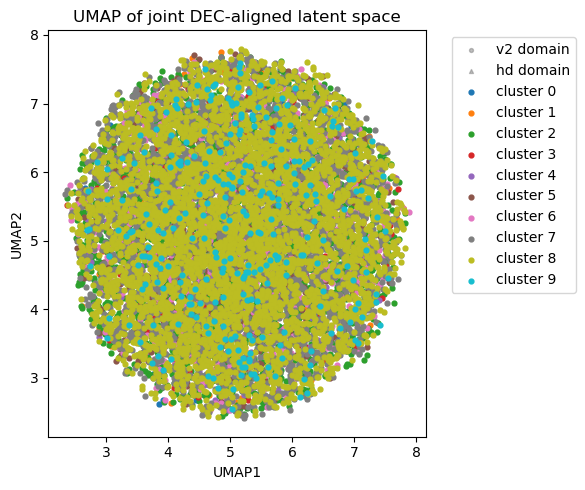

In [67]:
import umap
import matplotlib.pyplot as plt

Z_all   = np.vstack([Z_v2, Z_hd])
labels  = np.array(['v2']*Z_v2.shape[0] + ['hd']*Z_hd.shape[0])
clusts  = np.concatenate([labels_v2, labels_hd])

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
emb     = reducer.fit_transform(Z_all)

plt.figure(figsize=(6,5))
for dom, marker in zip(['v2','hd'], ['o','^']):
    idx = labels==dom
    plt.scatter(emb[idx,0], emb[idx,1],
                c='grey', marker=marker, s=8, alpha=0.5, label=f"{dom} domain")
# overlay clusters
for k in np.unique(clusts):
    idx = clusts==k
    plt.scatter(emb[idx,0], emb[idx,1],
                s=12, label=f"cluster {k}")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("UMAP of joint DEC‐aligned latent space")
plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
plt.tight_layout()
plt.show()


In [68]:
import scanpy as sc
import anndata

# Visium v2 AnnData
adata_v2_new = anndata.AnnData(Z_v2)
adata_v2_new.obs['dec_label'] = labels_v2
adata_v2_new.obs['domain']    = 'v2'

# Visium HD AnnData
adata_hd_new = anndata.AnnData(Z_hd)
adata_hd_new.obs['dec_label'] = labels_hd
adata_hd_new.obs['domain']    = 'hd'

# Joint AnnData
Z_joint = np.vstack([Z_v2, Z_hd])
obs = dict(domain = ['v2']*Z_v2.shape[0] + ['hd']*Z_hd.shape[0],
           dec_label = list(labels_v2) + list(labels_hd))
adata_joint = anndata.AnnData(Z_joint, obs=pd.DataFrame(obs))


aligned_df.py (68): Transforming to str index.


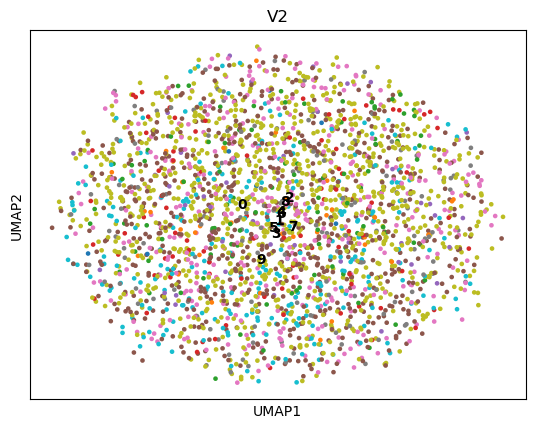

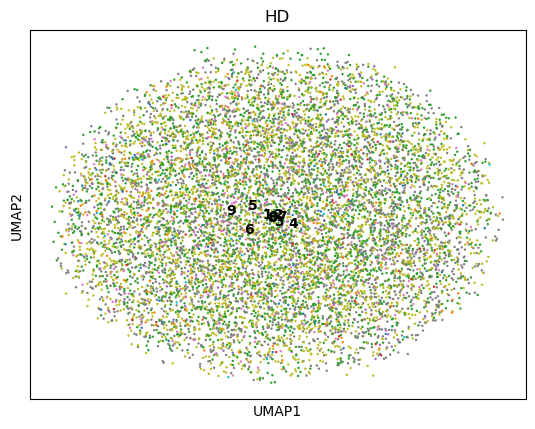

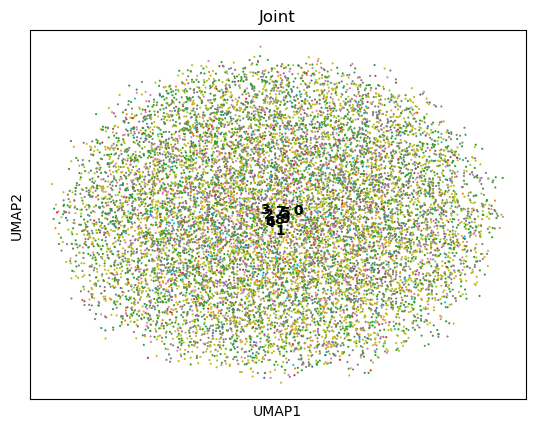

In [69]:
for ad, title in [(adata_v2_new, 'V2'), (adata_hd_new, 'HD'), (adata_joint, 'Joint')]:
    sc.pp.neighbors(ad, use_rep='X', n_neighbors=15)
    sc.tl.umap(ad, min_dist=0.2)
    sc.pl.umap(ad, color='dec_label', title=title, legend_loc='on data')


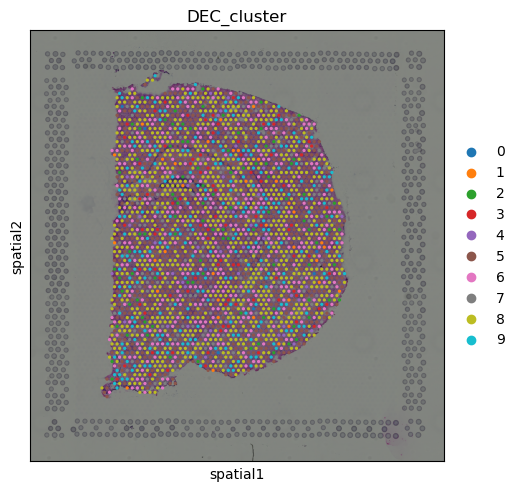

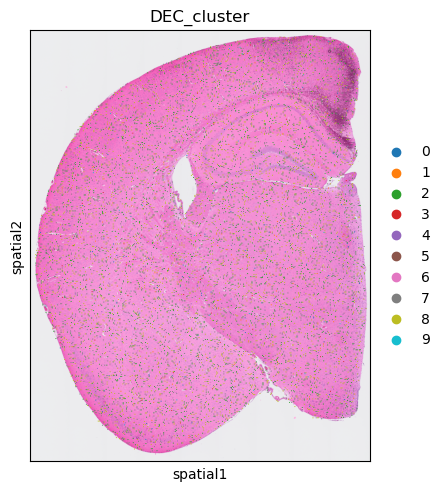

In [70]:
adata_v2_subset.obs['DEC_cluster'] = adata_v2_new.obs['dec_label'].values
adata_hd_subset.obs['DEC_cluster'] = adata_hd_new.obs['dec_label'].values

import squidpy as sq
sq.pl.spatial_scatter(adata_v2_subset, color='DEC_cluster', size=1)
sq.pl.spatial_scatter(adata_hd_subset, color='DEC_cluster', size=1)


_rank_genes_groups.py (458): overflow encountered in expm1
_rank_genes_groups.py (459): overflow encountered in expm1
_rank_genes_groups.py (458): invalid value encountered in divide
_rank_genes_groups.py (458): overflow encountered in expm1
_rank_genes_groups.py (459): overflow encountered in expm1
_rank_genes_groups.py (458): invalid value encountered in divide
_rank_genes_groups.py (461): divide by zero encountered in log2
_rank_genes_groups.py (458): overflow encountered in expm1
_rank_genes_groups.py (459): overflow encountered in expm1
_rank_genes_groups.py (458): invalid value encountered in divide
_rank_genes_groups.py (461): divide by zero encountered in log2
_rank_genes_groups.py (458): overflow encountered in expm1
_rank_genes_groups.py (459): overflow encountered in expm1
_rank_genes_groups.py (458): invalid value encountered in divide
_rank_genes_groups.py (458): overflow encountered in expm1
_rank_genes_groups.py (459): overflow encountered in expm1
_rank_genes_groups.py 

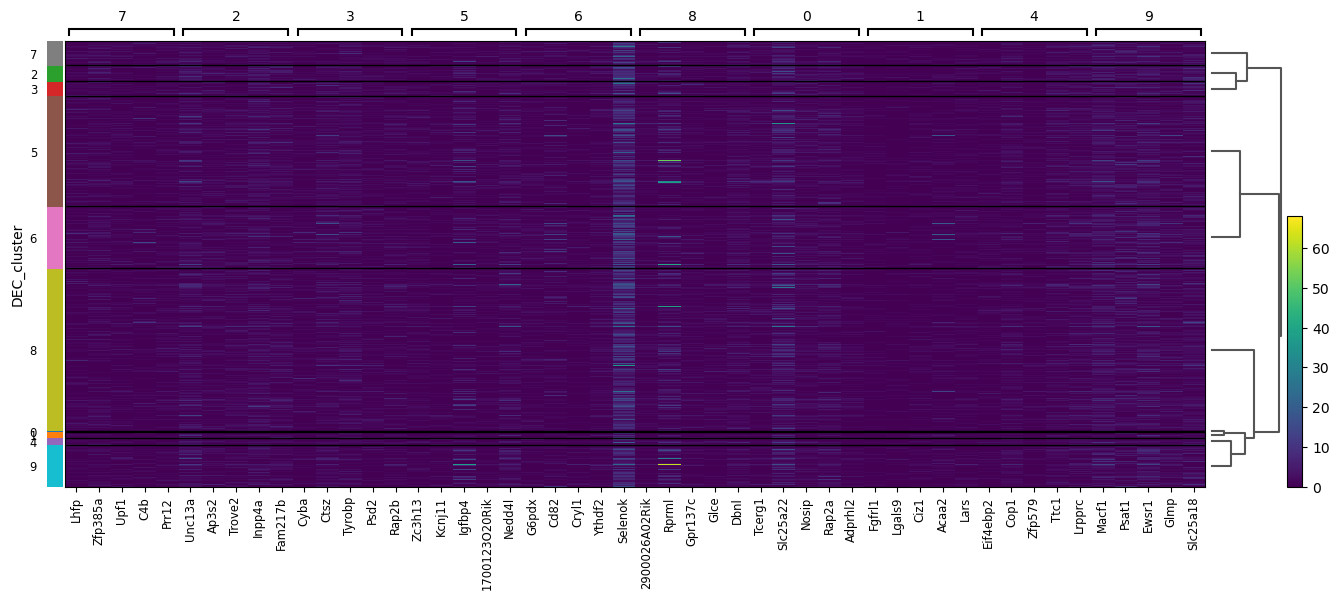

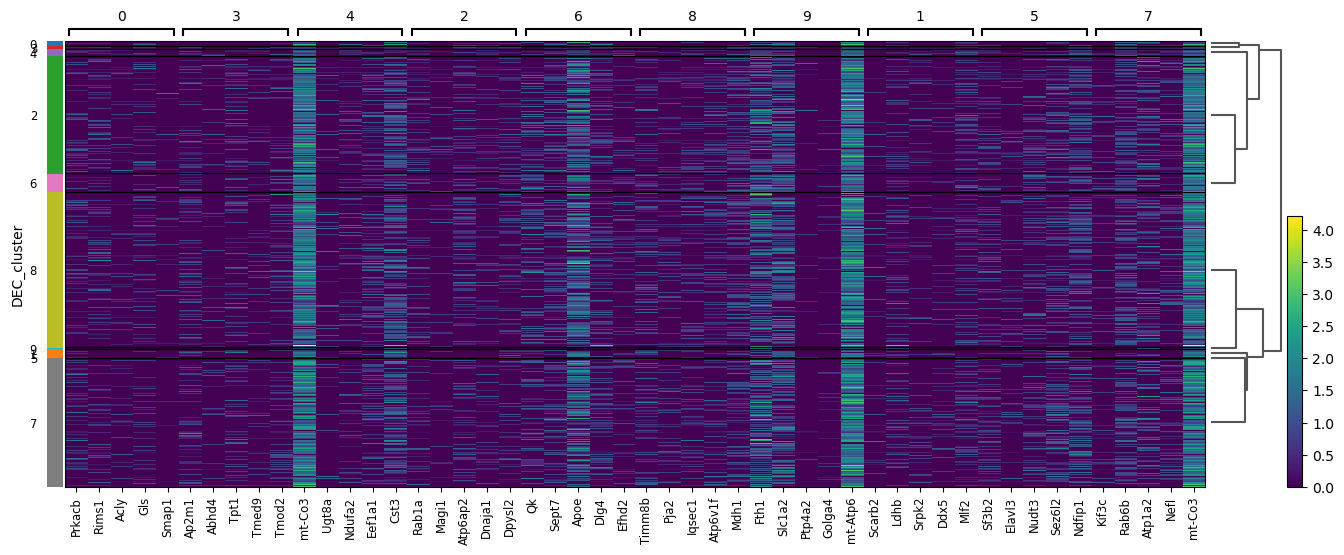

In [71]:
# On original counts but grouped by DEC clusters
sc.tl.rank_genes_groups(adata_v2_subset, groupby='DEC_cluster', method='wilcoxon')
sc.pl.rank_genes_groups_heatmap(adata_v2_subset, n_genes=5)

sc.tl.rank_genes_groups(adata_hd_subset, groupby='DEC_cluster', method='wilcoxon')
sc.pl.rank_genes_groups_heatmap(adata_hd_subset, n_genes=5)
